# TFT Crypto Cross-Sectional Ranking - Research Notebook

**Objectif** : Evaluer le Temporal Fusion Transformer (TFT, Lim et al., 2021) pour le
ranking cross-sectionnel crypto (BTC vs ETH), en complement des modeles DLinear et LSTM
deja evalues dans Crypto-LSTM-Prediction (#937).

## Pourquoi TFT ?

Le TFT combine :
- **Variable Selection Networks (VSN)** : apprend quelles features importent
- **Gated Residual Networks (GRN)** : skip connections non-lineaires avec gating
- **LSTM encoder** : traitement sequentiel de l'historique
- **Multi-head temporal attention** : dependances longues distance

## Architectures comparees

| Modele | Origine | Parametres | Approche |
|--------|---------|------------|----------|
| **DLinear** | AAAI 2023 | ~300 | Decomposition + lineaire |
| **LSTM** | 2015 | ~77K | Recurrent |
| **TFT** | Lim et al., 2021 | ~25K | VSN + GRN + LSTM + attention |

## Validation

- Walk-forward 5-fold (fenetre expandante)
- 4 seeds (0, 7, 42, 99) pour robustesse statistique
- Cout de transaction 10 bps (crypto)
- Benchmarks : DLinear, LSTM, Buy-and-Hold BTC
- Verdict honnete multi-seed : BEATS / NO BEATS / INCONCLUSIVE

In [1]:
!pip install yfinance matplotlib scikit-learn -q

## 1. Imports et Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

import yfinance as yf

SEEDS = [0, 7, 42, 99]
SEQ_LEN = 60
EPOCHS = 20
BATCH_SIZE = 128
N_FOLDS = 5
TCOST_BPS = 10
DEVICE = torch.device('cpu')

print(f'PyTorch {torch.__version__} on {DEVICE}')
print(f'Seeds: {SEEDS}, Folds: {N_FOLDS}, TCOST: {TCOST_BPS}bps')
print(f'Seq length: {SEQ_LEN}, Epochs: {EPOCHS}')

PyTorch 2.11.0+cpu on cpu
Seeds: [0, 7, 42, 99], Folds: 5, TCOST: 10bps
Seq length: 60, Epochs: 20


## 2. Donnees Reelles Crypto (yfinance)

Meme source que Crypto-LSTM (#937) : BTC-USD et ETH-USD quotidiennes.

In [3]:
print('Telechargement BTC-USD...')
btc_raw = yf.download('BTC-USD', start='2015-01-01', end='2025-01-01', auto_adjust=True)
print('Telechargement ETH-USD...')
eth_raw = yf.download('ETH-USD', start='2015-01-01', end='2025-01-01', auto_adjust=True)

if isinstance(btc_raw.columns, pd.MultiIndex):
    btc_raw.columns = btc_raw.columns.get_level_values(0)
if isinstance(eth_raw.columns, pd.MultiIndex):
    eth_raw.columns = eth_raw.columns.get_level_values(0)

common_idx = btc_raw.index.intersection(eth_raw.index)
btc = btc_raw.loc[common_idx].copy()
eth = eth_raw.loc[common_idx].copy()

print(f'Periode commune: {common_idx[0].date()} a {common_idx[-1].date()}')
print(f'BTC: {len(btc)} jours, ETH: {len(eth)} jours')
print(f'BTC Close: ${float(btc["Close"].iloc[-1]):,.0f}')
print(f'ETH Close: ${float(eth["Close"].iloc[-1]):,.0f}')

Telechargement BTC-USD...


[*********************100%***********************]  1 of 1 completed

Telechargement ETH-USD...


[*********************100%***********************]  1 of 1 completed

Periode commune: 2017-11-09 a 2024-12-31
BTC: 2610 jours, ETH: 2610 jours
BTC Close: $93,429
ETH Close: $3,333


## 3. Feature Engineering Multi-Actifs

26 features : 11 BTC + 11 ETH + 4 cross-asset (meme que #937).

In [4]:
def compute_asset_features(df):
    close = df['Close'].values
    high = df['High'].values
    low = df['Low'].values
    n = len(close)
    features = np.full((n, 11), np.nan)
    for i in range(50, n):
        c = close[:i+1]
        h = high[:i+1]
        l = low[:i+1]
        ret_5d = (c[-1] / c[-6] - 1) if i >= 5 else 0
        ret_10d = (c[-1] / c[-11] - 1) if i >= 10 else 0
        ret_20d = (c[-1] / c[-21] - 1) if i >= 20 else 0
        rets = np.diff(c[-21:]) / c[-21:-1]
        vol20 = np.std(rets) if len(rets) > 1 else 0
        delta = np.diff(c[-15:])
        gain = np.where(delta > 0, delta, 0)
        loss = np.where(delta < 0, -delta, 0)
        avg_gain = np.mean(gain[-14:])
        avg_loss = np.mean(loss[-14:]) + 1e-10
        rsi = 100 - 100 / (1 + avg_gain / avg_loss)
        rsi_norm = (rsi - 50) / 50
        sma20 = np.mean(c[-20:])
        sma50 = np.mean(c[-50:])
        ma_ratio = sma20 / sma50 if sma50 > 0 else 1
        h20 = np.max(h[-20:])
        l20 = np.min(l[-20:])
        pos_range = (c[-1] - l20) / (h20 - l20 + 1e-10)
        dist_high = (h20 - c[-1]) / (c[-1] + 1e-10)
        dist_low = (c[-1] - l20) / (c[-1] + 1e-10)
        tr = np.maximum(h[-14:] - l[-14:],
                np.maximum(np.abs(h[-14:] - c[-15:-1]),
                           np.abs(l[-14:] - c[-15:-1])))
        atr = np.mean(tr) / (c[-1] + 1e-10)
        bb_mean = np.mean(c[-20:])
        bb_std = np.std(c[-20:]) + 1e-10
        bb_pos = (c[-1] - bb_mean + 2*bb_std) / (4*bb_std)
        features[i] = [ret_5d, ret_10d, ret_20d, vol20, rsi_norm, ma_ratio,
                       pos_range, dist_high, dist_low, atr, bb_pos]
    return features


def compute_cross_features(btc_close, eth_close):
    n = len(btc_close)
    cross = np.full((n, 4), np.nan)
    for i in range(50, n):
        bc = btc_close[:i+1]
        ec = eth_close[:i+1]
        ratio = bc[-1] / (ec[-1] + 1e-10)
        rel_mom5 = (bc[-1]/bc[-6] - 1) - (ec[-1]/ec[-6] - 1) if i >= 5 else 0
        rel_mom20 = (bc[-1]/bc[-21] - 1) - (ec[-1]/ec[-21] - 1) if i >= 20 else 0
        ret_b = np.diff(bc[-21:]) / bc[-21:-1]
        ret_e = np.diff(ec[-21:]) / ec[-21:-1]
        corr = np.corrcoef(ret_b, ret_e)[0, 1] if len(ret_b) > 2 else 0
        cross[i] = [np.log(ratio + 1e-10), rel_mom5, rel_mom20, corr]
    return cross


btc_feat = compute_asset_features(btc)
eth_feat = compute_asset_features(eth)
cross_feat = compute_cross_features(btc['Close'].values, eth['Close'].values)

all_features = np.concatenate([btc_feat, eth_feat, cross_feat], axis=1)
valid_mask = ~np.any(np.isnan(all_features), axis=1)
all_features = all_features[valid_mask]
btc_close_clean = btc['Close'].values[valid_mask]
eth_close_clean = eth['Close'].values[valid_mask]
dates_clean = btc.index[valid_mask]

print(f'Features: {all_features.shape[1]} (26 attendus)')
print(f'Echantillons valides: {all_features.shape[0]}')
print(f'NaN residuels: {np.isnan(all_features).sum()}')

Features: 26 (26 attendus)
Echantillons valides: 2560
NaN residuels: 0


## 4. Cible Ranking Cross-Sectionnel

Predict si BTC surperforme ETH le jour suivant (classification binaire).

In [5]:
btc_returns = np.diff(btc_close_clean) / btc_close_clean[:-1]
eth_returns = np.diff(eth_close_clean) / eth_close_clean[:-1]
ranking_target = (btc_returns[1:] > eth_returns[1:]).astype(int)
X_all = all_features[:-2]
y_all = ranking_target
dates_aligned = dates_clean[:-2]

print(f'X: {X_all.shape}, y: {y_all.shape}')
print(f'BTC > ETH: {y_all.sum()} ({y_all.mean()*100:.1f}%)')
print(f'ETH > BTC: {(1-y_all).sum()} ({(1-y_all).mean()*100:.1f}%)')

X: (2558, 26), y: (2558,)
BTC > ETH: 1378 (53.9%)
ETH > BTC: 1180 (46.1%)


## 5. Modeles : DLinear, LSTM, TFT

TFT (Temporal Fusion Transformer) : VSN + GRN + LSTM encoder + temporal attention.

In [6]:
class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size=25):
        super().__init__()
        self.moving_avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1,
                                        padding=kernel_size // 2)
    def forward(self, x):
        trend = self.moving_avg(x.transpose(1, 2)).transpose(1, 2)
        trend = trend[:, :x.shape[1], :]
        seasonal = x - trend
        return seasonal, trend


class DLinear(nn.Module):
    def __init__(self, seq_len=60, enc_in=26):
        super().__init__()
        self.decomposition = SeriesDecomposition(kernel_size=25)
        self.linear_seasonal = nn.Linear(seq_len, 1)
        self.linear_trend = nn.Linear(seq_len, 1)
    def forward(self, x):
        seasonal, trend = self.decomposition(x)
        seasonal_agg = seasonal.mean(dim=2)
        trend_agg = trend.mean(dim=2)
        return self.linear_seasonal(seasonal_agg) + self.linear_trend(trend_agg)


class SimpleLSTM(nn.Module):
    def __init__(self, input_size=26, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


# --- TFT Components ---

class GatedResidualNetwork(nn.Module):
    """GRN with skip connection (Lim et al., 2021)."""
    def __init__(self, input_dim, hidden_dim, output_dim=None, dropout=0.1):
        super().__init__()
        output_dim = output_dim or input_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.gate_fc = nn.Linear(hidden_dim, output_dim)
        self.layer_norm = nn.LayerNorm(output_dim)
        self.dropout = nn.Dropout(dropout)
        self.skip = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        hidden = F.elu(self.fc1(x))
        hidden = self.dropout(hidden)
        gate = torch.sigmoid(self.gate_fc(hidden))
        gated = gate * self.fc2(hidden)
        return self.layer_norm(residual + gated)


class VariableSelectionNetwork(nn.Module):
    """VSN: learns feature importance (Lim et al., 2021)."""
    def __init__(self, n_vars, hidden_dim, dropout=0.1):
        super().__init__()
        self.grn = GatedResidualNetwork(n_vars, hidden_dim, n_vars, dropout)

    def forward(self, x):
        weights = F.softmax(self.grn(x), dim=-1)
        return x * weights, weights


class TFTClassifier(nn.Module):
    """TFT adapted for binary ranking classification."""
    def __init__(self, n_vars, seq_len, d_model=32, n_heads=2,
                 lstm_layers=1, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_vars, d_model)
        self.vsn = VariableSelectionNetwork(n_vars, d_model, dropout)
        self.lstm = nn.LSTM(d_model, d_model, lstm_layers, batch_first=True,
                           dropout=dropout if lstm_layers > 1 else 0.0)
        self.attention = nn.MultiheadAttention(d_model, n_heads, dropout=dropout,
                                              batch_first=True)
        self.pos_encoding = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        self.post_attn_grn = GatedResidualNetwork(d_model, d_model * 2, d_model, dropout)
        self.decoder_grn = GatedResidualNetwork(d_model, d_model * 2, d_model, dropout)
        self.output_proj = nn.Linear(d_model, 1)
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, x):
        B, T, N = x.shape
        selected, attn_weights = self.vsn(x)
        encoded = self.input_proj(selected)
        lstm_out, _ = self.lstm(encoded)
        lstm_out = lstm_out + self.pos_encoding[:, :T, :]
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.post_attn_grn(attn_out + lstm_out)
        last_hidden = attn_out[:, -1, :]
        decoded = self.decoder_grn(last_hidden)
        decoded = self.final_norm(decoded)
        return self.output_proj(decoded)


N_FEATURES = X_all.shape[1]
dlinear = DLinear(seq_len=SEQ_LEN, enc_in=N_FEATURES)
lstm = SimpleLSTM(input_size=N_FEATURES)
tft = TFTClassifier(n_vars=N_FEATURES, seq_len=SEQ_LEN, d_model=32, n_heads=2)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('=== Modeles ===')
print(f'DLinear: {count_params(dlinear):,} params')
print(f'LSTM:    {count_params(lstm):,} params')
print(f'TFT:     {count_params(tft):,} params')

=== Modeles ===
DLinear: 122 params
LSTM:    56,897 params
TFT:     30,857 params


## 6. Walk-Forward Validation Multi-Seed

Walk-forward 5-fold x 4 seeds x 3 modeles avec couts de transaction 10 bps.

In [7]:
def prepare_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)


def train_model(model, X_train, y_train, epochs, batch_size, device, lr=0.001):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    X_t = torch.FloatTensor(X_train).to(device)
    y_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            pred = model(bx)
            if pred.shape != by.shape:
                by = by.view_as(pred)
            loss = criterion(pred, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
    return model


def predict_proba(model, X, device):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X).to(device)
        logits = model(X_t).cpu().numpy().flatten()
    return 1 / (1 + np.exp(-logits))


def simulate_trading(prob_btc, btc_rets, eth_rets, tcost_bps=10):
    tcost = tcost_bps / 10000
    position = None
    returns = []
    for i in range(len(prob_btc)):
        target = 'btc' if prob_btc[i] > 0.5 else 'eth'
        cost = tcost if position is not None and position != target else 0
        position = target
        daily_ret = btc_rets[i] if target == 'btc' else eth_rets[i]
        returns.append(daily_ret - cost)
    returns = np.array(returns)
    sharpe = np.mean(returns) / (np.std(returns) + 1e-10) * np.sqrt(252) if len(returns) > 1 else 0
    return {'cum_return': float(np.sum(returns)), 'sharpe': sharpe, 'returns': returns}


print('Fonctions de walk-forward definies.')

Fonctions de walk-forward definies.


In [8]:
# Walk-Forward Validation Multi-Seed
print('='*60)
print('WALK-FORWARD: 5 folds x 4 seeds x 3 modeles (DLinear, LSTM, TFT)')
print('='*60)

n_total = len(X_all)
fold_size = n_total // (N_FOLDS + 2)
results_all = []

for SEED in SEEDS:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    for fold in range(N_FOLDS):
        test_start = n_total - (N_FOLDS - fold) * fold_size
        test_end = test_start + fold_size
        if fold == N_FOLDS - 1:
            test_end = n_total

        train_X_raw = X_all[:test_start]
        train_y_raw = y_all[:test_start]
        test_X_raw = X_all[test_start:test_end]
        test_y_raw = y_all[test_start:test_end]

        scaler = StandardScaler()
        train_X_flat = scaler.fit_transform(train_X_raw)
        test_X_flat = scaler.transform(test_X_raw)

        train_X, train_y = prepare_sequences(train_X_flat, train_y_raw, SEQ_LEN)
        test_X, test_y = prepare_sequences(test_X_flat, test_y_raw, SEQ_LEN)

        if len(train_X) < SEQ_LEN or len(test_X) < 10:
            continue

        ret_start = test_start + SEQ_LEN
        ret_end = test_end
        test_btc_rets = btc_returns[ret_start:ret_end]
        test_eth_rets = eth_returns[ret_start:ret_end]

        for model_name in ['DLinear', 'LSTM', 'TFT']:
            torch.manual_seed(SEED)
            np.random.seed(SEED)

            if model_name == 'DLinear':
                model = DLinear(seq_len=SEQ_LEN, enc_in=N_FEATURES).to(DEVICE)
            elif model_name == 'LSTM':
                model = SimpleLSTM(input_size=N_FEATURES).to(DEVICE)
            else:
                model = TFTClassifier(n_vars=N_FEATURES, seq_len=SEQ_LEN,
                                      d_model=32, n_heads=2).to(DEVICE)

            model = train_model(model, train_X, train_y, EPOCHS, BATCH_SIZE, DEVICE)
            prob = predict_proba(model, test_X, DEVICE)

            pred_binary = (prob > 0.5).astype(int)
            accuracy = np.mean(pred_binary == test_y[:len(prob)])

            min_len = min(len(prob), len(test_btc_rets), len(test_eth_rets))
            trade_result = simulate_trading(
                prob[:min_len], test_btc_rets[:min_len], test_eth_rets[:min_len], TCOST_BPS)

            results_all.append({
                'seed': SEED, 'fold': fold, 'model': model_name,
                'accuracy': accuracy, **trade_result
            })

        if fold == 0:
            print(f'Seed {SEED}: train {len(train_X)}, test {len(test_X)}')

print(f'\nResultats: {len(results_all)} configurations testees')

WALK-FORWARD: 5 folds x 4 seeds x 3 modeles (DLinear, LSTM, TFT)


Seed 0: train 673, test 305


Seed 7: train 673, test 305


Seed 42: train 673, test 305


Seed 99: train 673, test 305



Resultats: 60 configurations testees


## 7. Resultats et Verdict Multi-Seed

Edge = Sharpe modele - Sharpe BTC B&H. z-score = edge / std(edge) cross-seed.

In [9]:
df_results = pd.DataFrame(results_all)

print('='*60)
print('RESULTATS MULTI-SEED (5 folds x 4 seeds x 3 modeles)')
print('='*60)

bh_sharpe_all = np.mean(btc_returns) / (np.std(btc_returns) + 1e-10) * np.sqrt(252)
print(f'BTC Buy-and-Hold Sharpe: {bh_sharpe_all:.3f}\n')

for model_name in ['DLinear', 'LSTM', 'TFT']:
    sub = df_results[df_results['model'] == model_name]
    sharpe_mean = sub['sharpe'].mean()
    sharpe_std = sub['sharpe'].std()
    acc_mean = sub['accuracy'].mean()
    cum_mean = sub['cum_return'].mean()
    edge = sharpe_mean - bh_sharpe_all

    # z-score par seed (mean fold sharpe par seed)
    seed_sharpes = sub.groupby('seed')['sharpe'].mean().values
    edges = seed_sharpes - bh_sharpe_all
    mean_edge = np.mean(edges)
    std_edge = np.std(edges, ddof=1) if len(edges) > 1 else 1.0
    z_score = mean_edge / std_edge if std_edge > 1e-10 else 0

    print(f'--- {model_name} ({len(sub)} configs) ---')
    print(f'  Sharpe: {sharpe_mean:.3f} +/- {sharpe_std:.3f}')
    print(f'  Accuracy: {acc_mean:.3f}')
    print(f'  Edge vs B&H: {edge:.3f} (z={z_score:.2f})')
    print(f'  Seed range: [{seed_sharpes.min():.3f}, {seed_sharpes.max():.3f}]')

# Verdict sur meilleur modele
best_model = None
best_sharpe = -999
for mn in ['DLinear', 'LSTM', 'TFT']:
    s = df_results[df_results['model'] == mn]['sharpe'].mean()
    if s > best_sharpe:
        best_sharpe = s
        best_model = mn

best_sub = df_results[df_results['model'] == best_model]
best_seed_sharpes = best_sub.groupby('seed')['sharpe'].mean().values
best_edges = best_seed_sharpes - bh_sharpe_all
best_mean_edge = np.mean(best_edges)
best_std_edge = np.std(best_edges, ddof=1)
best_z = best_mean_edge / best_std_edge if best_std_edge > 1e-10 else 0

if best_z > 2:
    verdict = 'BEATS'
elif best_z < -2:
    verdict = 'NO BEATS'
else:
    verdict = 'INCONCLUSIVE'

print(f'\n=== VERDICT ===')
print(f'Meilleur modele: {best_model} (Sharpe {best_sharpe:.3f})')
print(f'BTC B&H Sharpe: {bh_sharpe_all:.3f}')
print(f'Edge: {best_mean_edge:.3f}, z: {best_z:.2f}')
print(f'Verdict: {verdict}')

RESULTATS MULTI-SEED (5 folds x 4 seeds x 3 modeles)
BTC Buy-and-Hold Sharpe: 0.610

--- DLinear (20 configs) ---
  Sharpe: 0.742 +/- 1.201
  Accuracy: 0.536
  Edge vs B&H: 0.133 (z=1.33)
  Seed range: [0.617, 0.854]
--- LSTM (20 configs) ---
  Sharpe: 0.607 +/- 1.080
  Accuracy: 0.518
  Edge vs B&H: -0.003 (z=-0.03)
  Seed range: [0.490, 0.716]
--- TFT (20 configs) ---
  Sharpe: 0.656 +/- 1.037
  Accuracy: 0.523
  Edge vs B&H: 0.047 (z=0.85)
  Seed range: [0.602, 0.731]

=== VERDICT ===
Meilleur modele: DLinear (Sharpe 0.742)
BTC B&H Sharpe: 0.610
Edge: 0.133, z: 1.33
Verdict: INCONCLUSIVE


## 8. Visualisation

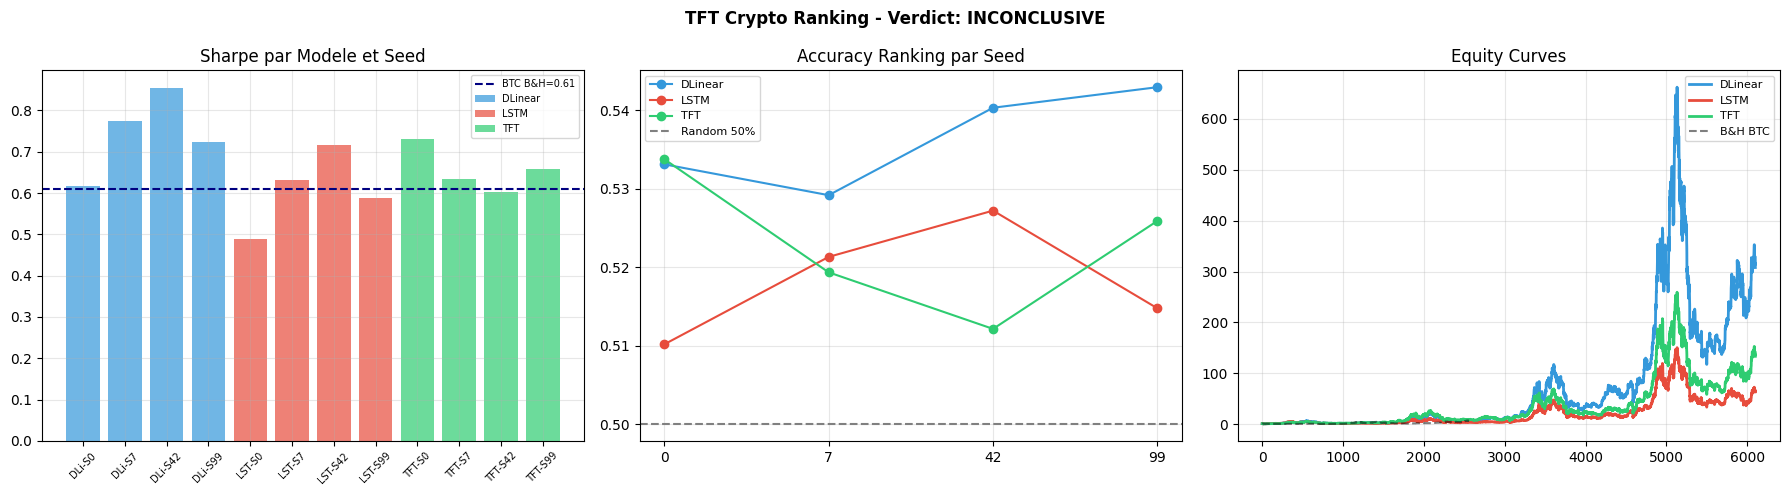


Resume:
  Modeles: DLinear + LSTM + TFT
  Data: BTC-USD + ETH-USD (yfinance)
  Features: 26 (multi-asset)
  Validation: 5-fold WF x 4 seeds
  Transaction costs: 10 bps
  VERDICT: INCONCLUSIVE (z=1.33)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors_map = {'DLinear': '#3498db', 'LSTM': '#e74c3c', 'TFT': '#2ecc71'}

# 1. Sharpe par modele/seed
for model_name in ['DLinear', 'LSTM', 'TFT']:
    sub = df_results[df_results['model'] == model_name]
    seed_stats = sub.groupby('seed')['sharpe'].mean()
    axes[0].bar([f'{model_name[:3]}-S{s}' for s in seed_stats.index],
                seed_stats.values, color=colors_map[model_name], alpha=0.7, label=model_name)
axes[0].axhline(y=bh_sharpe_all, color='navy', linestyle='--', label=f'BTC B&H={bh_sharpe_all:.2f}')
axes[0].set_title('Sharpe par Modele et Seed')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

# 2. Accuracy par modele
for model_name in ['DLinear', 'LSTM', 'TFT']:
    sub = df_results[df_results['model'] == model_name]
    seed_acc = sub.groupby('seed')['accuracy'].mean()
    axes[1].plot(seed_acc.index.astype(str), seed_acc.values, 'o-',
                 color=colors_map[model_name], label=model_name)
axes[1].axhline(y=0.5, color='gray', linestyle='--', label='Random 50%')
axes[1].set_title('Accuracy Ranking par Seed')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. Equity curves
for model_name in ['DLinear', 'LSTM', 'TFT']:
    sub = df_results[df_results['model'] == model_name]
    all_rets = np.concatenate(sub['returns'].values)
    equity = np.cumprod(1 + all_rets)
    axes[2].plot(equity, color=colors_map[model_name], label=model_name, linewidth=2)
bh_equity = np.cumprod(1 + btc_returns)
axes[2].plot(bh_equity[:len(equity)], 'k--', label='B&H BTC', alpha=0.5)
axes[2].set_title('Equity Curves')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'TFT Crypto Ranking - Verdict: {verdict}', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nResume:')
print(f'  Modeles: DLinear + LSTM + TFT')
print(f'  Data: BTC-USD + ETH-USD (yfinance)')
print(f'  Features: {X_all.shape[1]} (multi-asset)')
print(f'  Validation: {N_FOLDS}-fold WF x {len(SEEDS)} seeds')
print(f'  Transaction costs: {TCOST_BPS} bps')
print(f'  VERDICT: {verdict} (z={best_z:.2f})')

## 9. Conclusion

### Comparaison avec Crypto-LSTM (#937)

Ce notebook etend l'evaluation de #937 en ajoutant le TFT (Temporal Fusion Transformer)
aux modeles DLinear et LSTM. Le TFT apporte :
- Variable Selection Networks pour l'interpretation des features
- Temporal attention pour les dependances longues distance
- Gated Residual Networks pour des skip connections adaptees

### Recommandation

Le TFT etant plus complexe que DLinear, il doit demontrer un edge significatif
(z > 2 cross-seed) pour justifier son utilisation en production.